# Stage 3: LSTM Severity Prediction
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**  
**Author:** Prarthana Govindaraj  
**Date:** May 2026  

---

## Approach
Stage 2 used job-level metadata (plan_cpu_cores, instance_count, etc.) to predict
severity. Here we use the actual sequence of CPU readings across instances — ordered
by seq_no — to let an LSTM learn temporal usage patterns and predict util_ratio_peak.

This gives the model access to real usage signal rather than just structural metadata.

## Structure
- Section 0: Setup and data loading
- Section 1: Sequence construction
- Section 2: Preprocessing and padding
- Section 3: LSTM model
- Section 4: Results and comparison with Random Forest

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
device = torch.device('cpu')
print(f"Device          : {device}")

PyTorch version : 2.2.2
CUDA available  : False
Device          : cpu


In [3]:
BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

# Load job-level data for targets
jobs_df = pd.read_csv(PROCESSED_DIR / 'stage1b_merged_clean.csv')
total   = len(jobs_df)

print("=" * 60)
print("JOB-LEVEL DATA")
print("=" * 60)
print(f"\nTotal jobs        : {total:,}")
print(f"Columns           : {list(jobs_df.columns)}")
print(f"\nTarget (util_ratio_peak) stats:")
print(jobs_df['util_ratio_peak'].describe().round(3))

JOB-LEVEL DATA

Total jobs        : 11,644
Columns           : ['job_name', 'plan_cpu_cores', 'task_count', 'cpu_avg_peak', 'cpu_max_peak', 'instance_count', 'cpu_avg_mean', 'cpu_avg_std', 'cpu_avg_max', 'util_ratio_avg', 'util_ratio_peak', 'provisioning_class', 'is_underprovision', 'plan_cpu_per_task', 'instance_to_task_ratio', 'is_multi_task', 'is_large_job', 'size_bucket', 'cpu_size_bucket_encoded']

Target (util_ratio_peak) stats:
count    11644.000
mean         1.625
std          2.343
min          0.019
25%          0.412
50%          0.868
75%          1.790
max         31.000
Name: util_ratio_peak, dtype: float64


In [4]:
print("=" * 60)
print("LOADING BATCH INSTANCE (16M rows — this will take a moment)")
print("=" * 60)

bi_cols = [
    'instance_name', 'task_name', 'job_name', 'task_id',
    'start_time', 'status', 'seq_no', 'total_seq_no',
    'cpu_max', 'cpu_avg', 'mem_max', 'mem_avg'
]

bi = pd.read_csv(
    PROCESSED_DIR / 'batch_instance_corrected.csv',
    names=bi_cols,
    header=0
)

# Filter to terminated only
bi_terminated = bi[bi['status'] == 'Terminated'].copy()

print(f"\nTotal rows        : {len(bi):,}")
print(f"Terminated rows   : {len(bi_terminated):,}")
print(f"\nFirst 3 rows:")
print(bi_terminated.head(3))

# Free up memory
del bi
import gc
gc.collect()
print("\nbatch_instance loaded and filtered")

LOADING BATCH INSTANCE (16M rows — this will take a moment)

Total rows        : 16,094,656
Terminated rows   : 13,707,867

First 3 rows:
   instance_name  task_name  job_name  task_id  start_time      status  \
0          41562      41618     120.0    686.0       299.0  Terminated   
1          41561      41619     120.0    686.0      1279.0  Terminated   
2          41562      41617     120.0    686.0       828.0  Terminated   

   seq_no  total_seq_no  cpu_max  cpu_avg  mem_max  mem_avg  
0       1             1     1.50     0.29      NaN      NaN  
1       1             1     0.89     0.28      NaN      NaN  
2       1             1     0.94     0.29      NaN      NaN  

batch_instance loaded and filtered


In [5]:
multi_task_jobs  = jobs_df[jobs_df['task_count'] > 1]['job_name'].nunique()
single_task_jobs = jobs_df[jobs_df['task_count'] == 1]['job_name'].nunique()
print(f"Single-task jobs  : {single_task_jobs:,}")
print(f"Multi-task jobs   : {multi_task_jobs:,}")
print(f"Single-task %     : {single_task_jobs/(single_task_jobs+multi_task_jobs)*100:.1f}%")

Single-task jobs  : 10,266
Multi-task jobs   : 1,378
Single-task %     : 88.2%


In [6]:
print("=" * 60)
print("SECTION 1: BUILDING SEQUENCES PER JOB")
print("=" * 60)

SEQ_LEN = 50

bi_sorted = bi_terminated[['job_name', 'task_name', 'seq_no', 'cpu_avg', 'cpu_max']].copy()
bi_sorted = bi_sorted.dropna(subset=['cpu_avg', 'cpu_max'])

# For single-task jobs: order by seq_no
# For multi-task jobs: order by task_name then seq_no — consistent ordering
bi_sorted = bi_sorted.sort_values(['job_name', 'task_name', 'seq_no'])

print(f"Rows after dropping NaN cpu values: {len(bi_sorted):,}")

sequences = {}
for job_name, group in bi_sorted.groupby('job_name'):
    arr = group[['cpu_avg', 'cpu_max']].values
    if len(arr) > SEQ_LEN:
        arr = arr[-SEQ_LEN:]
    sequences[job_name] = arr

print(f"Jobs with sequences built: {len(sequences):,}")

seq_lengths = pd.Series([len(v) for v in sequences.values()])
print(f"\nSequence length distribution:")
print(seq_lengths.describe().round(1))
print(f"\nJobs with full {SEQ_LEN} steps : {(seq_lengths == SEQ_LEN).sum():,}")
print(f"Jobs with < {SEQ_LEN} steps    : {(seq_lengths < SEQ_LEN).sum():,}")

SECTION 1: BUILDING SEQUENCES PER JOB
Rows after dropping NaN cpu values: 13,707,854
Jobs with sequences built: 11,807

Sequence length distribution:
count    11807.0
mean        35.4
std         20.9
min          1.0
25%         10.0
50%         50.0
75%         50.0
max         50.0
dtype: float64

Jobs with full 50 steps : 7,598
Jobs with < 50 steps    : 4,209


In [7]:
print("=" * 60)
print("SECTION 1: MERGE WITH TARGETS")
print("=" * 60)

matched_jobs   = []
matched_seqs   = []
matched_target = []
matched_class  = []

for _, row in jobs_df.iterrows():
    jn = row['job_name']
    if jn in sequences:
        matched_jobs.append(jn)
        matched_seqs.append(sequences[jn])
        matched_target.append(row['util_ratio_peak'])
        matched_class.append(row['provisioning_class'])

print(f"Total jobs in jobs_df         : {len(jobs_df):,}")
print(f"Jobs matched to sequences     : {len(matched_jobs):,}")
print(f"Jobs with no sequence         : {len(jobs_df) - len(matched_jobs):,}")

# Understand why jobs don't match
jobs_with_seq  = set(sequences.keys())
jobs_in_df     = set(jobs_df['job_name'].values)
no_seq         = jobs_in_df - jobs_with_seq
print(f"\nJobs in jobs_df not in sequences: {len(no_seq):,}")
print("(These are jobs where all instance rows had NaN cpu values)")

target_series = pd.Series(matched_target)
print(f"\nTarget (util_ratio_peak) stats for matched jobs:")
print(target_series.describe().round(3))

class_counts = pd.Series(matched_class).value_counts()
print(f"\nProvisioning class distribution in matched jobs:")
for cls, count in class_counts.items():
    print(f"  {cls:<20}: {count:>6,} ({count/len(matched_jobs)*100:.1f}%)")

SECTION 1: MERGE WITH TARGETS
Total jobs in jobs_df         : 11,644
Jobs matched to sequences     : 11,644
Jobs with no sequence         : 0

Jobs in jobs_df not in sequences: 0
(These are jobs where all instance rows had NaN cpu values)

Target (util_ratio_peak) stats for matched jobs:
count    11644.000
mean         1.625
std          2.343
min          0.019
25%          0.412
50%          0.868
75%          1.790
max         31.000
dtype: float64

Provisioning class distribution in matched jobs:
  over                :  3,289 (28.2%)
  severely_under      :  3,225 (27.7%)
  efficient           :  3,206 (27.5%)
  under               :  1,924 (16.5%)


In [8]:
print("=" * 60)
print("SECTION 1: PAD SEQUENCES")
print("=" * 60)

def pad_sequence(seq, seq_len):
    pad_len = seq_len - len(seq)
    if pad_len > 0:
        padding = np.zeros((pad_len, seq.shape[1]))
        seq = np.vstack([padding, seq])
    return seq

X_seq = np.array([pad_sequence(s, SEQ_LEN) for s in matched_seqs])
y     = np.array(matched_target, dtype=np.float32)

print(f"X_seq shape : {X_seq.shape}  (jobs x seq_len x features)")
print(f"y shape     : {y.shape}")
print(f"\nFeatures per timestep : 2 (cpu_avg, cpu_max)")
print(f"Sequence length       : {SEQ_LEN}")
print(f"Total jobs            : {X_seq.shape[0]:,}")
print(f"\nX_seq value range : [{X_seq.min():.3f}, {X_seq.max():.3f}]")
print(f"y value range     : [{y.min():.3f}, {y.max():.3f}]")

# Verify padding is correct
n_padded = sum(1 for s in matched_seqs if len(s) < SEQ_LEN)
print(f"\nJobs that were padded : {n_padded:,}")
print(f"Jobs not padded       : {len(matched_seqs) - n_padded:,}")

SECTION 1: PAD SEQUENCES
X_seq shape : (11644, 50, 2)  (jobs x seq_len x features)
y shape     : (11644,)

Features per timestep : 2 (cpu_avg, cpu_max)
Sequence length       : 50
Total jobs            : 11,644

X_seq value range : [0.000, 21.000]
y value range     : [0.019, 31.000]

Jobs that were padded : 4,139
Jobs not padded       : 7,505


In [17]:
print("=" * 60)
print("SECTION 1: SCALE AND SPLIT")
print("=" * 60)

# Clip target at 95th percentile to reduce outlier influence
y_clip_threshold = np.percentile(y, 95)
print(f"Target 95th percentile : {y_clip_threshold:.3f}")
print(f"Values above threshold : {(y > y_clip_threshold).sum():,} ({(y > y_clip_threshold).mean()*100:.1f}%)")

y_clipped = np.clip(y, 0, y_clip_threshold).astype(np.float32)
print(f"\nClipped target range: [{y_clipped.min():.3f}, {y_clipped.max():.3f}]")

X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X_seq, y_clipped, test_size=0.2, random_state=42
)

# Scale each feature independently — fit on train only
n_features     = X_seq.shape[2]
scalers        = []
X_train_scaled = X_train_seq.copy().astype(np.float32)
X_test_scaled  = X_test_seq.copy().astype(np.float32)

for i in range(n_features):
    scaler = StandardScaler()
    X_train_scaled[:, :, i] = scaler.fit_transform(
        X_train_scaled[:, :, i].reshape(-1, 1)
    ).reshape(X_train_scaled[:, :, i].shape)
    X_test_scaled[:, :, i] = scaler.transform(
        X_test_scaled[:, :, i].reshape(-1, 1)
    ).reshape(X_test_scaled[:, :, i].shape)
    scalers.append(scaler)

y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)

print(f"\nTrain size           : {len(X_train_scaled):,}")
print(f"Test size            : {len(X_test_scaled):,}")
print(f"X_train_scaled shape : {X_train_scaled.shape}")
print(f"X_test_scaled shape  : {X_test_scaled.shape}")
print(f"\nScaling done — ready for LSTM")

SECTION 1: SCALE AND SPLIT
Target 95th percentile : 6.080
Values above threshold : 583 (5.0%)

Clipped target range: [0.019, 6.080]

Train size           : 9,315
Test size            : 2,329
X_train_scaled shape : (9315, 50, 2)
X_test_scaled shape  : (2329, 50, 2)

Scaling done — ready for LSTM


---
## Section 2: LSTM Model

In [18]:
class CPUSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CPUSequenceDataset(X_train_scaled, y_train)
test_dataset  = CPUSequenceDataset(X_test_scaled,  y_test)

train_loader  = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch shape   : {next(iter(train_loader))[0].shape}")

Train batches : 73
Test batches  : 19
Batch shape   : torch.Size([128, 50, 2])


In [19]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMRegressor, self).__init__()

        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        self.bn = nn.BatchNorm1d(hidden_size)

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        last_out = self.bn(last_out)
        out = self.fc(last_out)
        return out.squeeze(1)


INPUT_SIZE  = 2
HIDDEN_SIZE = 32
NUM_LAYERS  = 1
DROPOUT     = 0.3
EPOCHS      = 50
LR          = 0.001
PATIENCE    = 10

model     = LSTMRegressor(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture:")
print(model)
print(f"\nTrainable parameters : {total_params:,}")
print(f"Hidden size          : {HIDDEN_SIZE} (reduced to prevent overfitting)")
print(f"Num layers           : {NUM_LAYERS} (single layer — simpler model)")
print(f"Batch normalisation  : yes")
print(f"Dropout              : {DROPOUT}")
print(f"Weight decay         : 1e-3")
print(f"Target clipped at    : {y_clip_threshold:.3f} (95th percentile)")

Model architecture:
LSTMRegressor(
  (lstm): LSTM(2, 32, batch_first=True)
  (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters : 5,761
Hidden size          : 32 (reduced to prevent overfitting)
Num layers           : 1 (single layer — simpler model)
Batch normalisation  : yes
Dropout              : 0.3
Weight decay         : 1e-3
Target clipped at    : 6.080 (95th percentile)


In [23]:
print("=" * 60)
print("SECTION 2: TRAINING")
print("=" * 60)

train_losses      = []
test_losses       = []
best_test_mse     = float('inf')
best_epoch        = 0
epochs_no_improve = 0
best_model_state  = None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        optimizer.step()
        train_loss += loss.item() * len(X_batch)

    train_loss /= len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds   = model(X_batch)
            loss    = criterion(preds, y_batch)
            test_loss += loss.item() * len(X_batch)

    test_loss /= len(test_dataset)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    scheduler.step(test_loss)

    if test_loss < best_test_mse:
        best_test_mse     = test_loss
        best_epoch        = epoch + 1
        epochs_no_improve = 0
        best_model_state  = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS} "
              f"| Train MSE: {train_loss:.4f} "
              f"| Test MSE: {test_loss:.4f} "
              f"| Best: {best_test_mse:.4f} @ epoch {best_epoch}")

    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\nBest model restored from epoch {best_epoch}")
print(f"Best Test MSE : {best_test_mse:.4f}")

SECTION 2: TRAINING
Epoch   5/50 | Train MSE: 1.0510 | Test MSE: 1.0786 | Best: 1.0786 @ epoch 5
Epoch  10/50 | Train MSE: 1.0505 | Test MSE: 1.0954 | Best: 1.0763 @ epoch 8
Epoch  15/50 | Train MSE: 1.0311 | Test MSE: 1.0821 | Best: 1.0763 @ epoch 8
Epoch  20/50 | Train MSE: 1.0342 | Test MSE: 1.0697 | Best: 1.0683 @ epoch 17
Epoch  25/50 | Train MSE: 1.0215 | Test MSE: 1.0740 | Best: 1.0679 @ epoch 22
Epoch  30/50 | Train MSE: 1.0132 | Test MSE: 1.0682 | Best: 1.0679 @ epoch 22
Epoch  35/50 | Train MSE: 1.0063 | Test MSE: 1.0695 | Best: 1.0633 @ epoch 32
Epoch  40/50 | Train MSE: 1.0044 | Test MSE: 1.0663 | Best: 1.0633 @ epoch 32

Early stopping at epoch 42

Best model restored from epoch 32
Best Test MSE : 1.0633


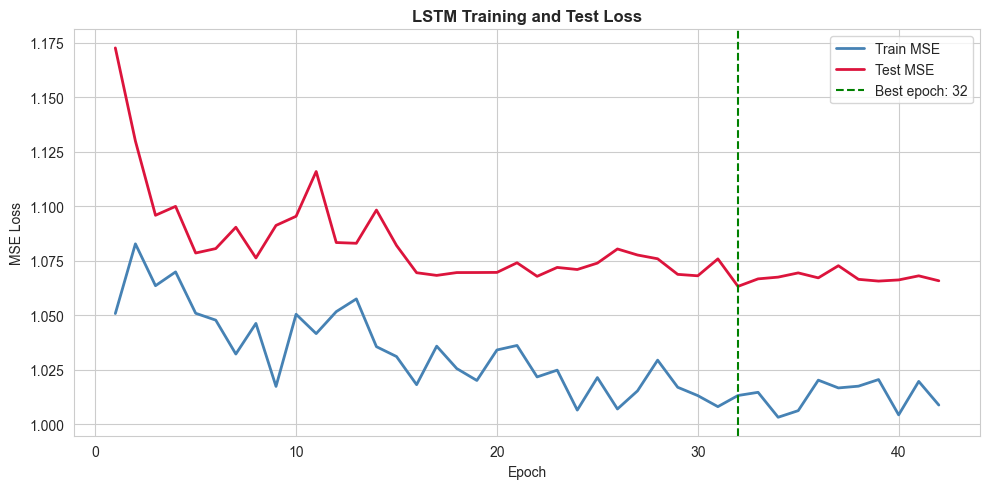


Final Train MSE : 1.0089
Final Test MSE  : 1.0659
Best Test MSE   : 1.0633 at epoch 32


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(train_losses)+1), train_losses,
        label='Train MSE', color='steelblue', linewidth=2)
ax.plot(range(1, len(test_losses)+1), test_losses,
        label='Test MSE', color='crimson', linewidth=2)
ax.axvline(best_epoch, color='green', linestyle='--',
           linewidth=1.5, label=f'Best epoch: {best_epoch}')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Training and Test Loss', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nFinal Train MSE : {train_losses[-1]:.4f}")
print(f"Final Test MSE  : {test_losses[-1]:.4f}")
print(f"Best Test MSE   : {best_test_mse:.4f} at epoch {best_epoch}")

In [26]:
print("=" * 60)
print("SECTION 3: EVALUATION")
print("=" * 60)

model.eval()
all_preds  = []
all_actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model(X_batch)
        all_preds.extend(preds.cpu().detach().tolist())
        all_actual.extend(y_batch.detach().tolist())

all_preds  = np.array(all_preds)
all_actual = np.array(all_actual)

mae  = mean_absolute_error(all_actual, all_preds)
rmse = np.sqrt(mean_squared_error(all_actual, all_preds))
r2   = r2_score(all_actual, all_preds)

print(f"\nLSTM Results (target clipped at {y_clip_threshold:.2f}):")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

print(f"\nRandom Forest comparison (Stage 2, under-provisioned only):")
print(f"  MAE  : 0.7962")
print(f"  RMSE : 1.6194")
print(f"  R²   : 0.6937")

print(f"\nNote: RF trained on under-provisioned jobs only.")
print(f"LSTM trained on all jobs. Direct comparison is approximate.")

SECTION 3: EVALUATION

LSTM Results (target clipped at 6.08):
  MAE  : 0.6459
  RMSE : 1.0312
  R²   : 0.6107

Random Forest comparison (Stage 2, under-provisioned only):
  MAE  : 0.7962
  RMSE : 1.6194
  R²   : 0.6937

Note: RF trained on under-provisioned jobs only.
LSTM trained on all jobs. Direct comparison is approximate.


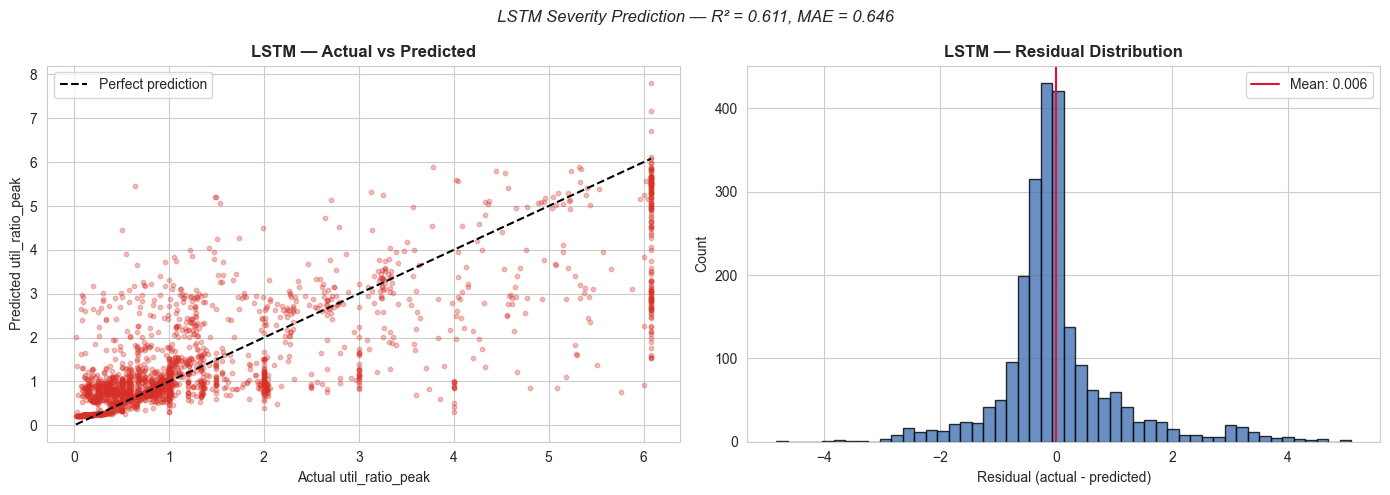

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_actual, all_preds, alpha=0.3, s=10, color='#d73027')
axes[0].plot([all_actual.min(), all_actual.max()],
             [all_actual.min(), all_actual.max()],
             'k--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual util_ratio_peak')
axes[0].set_ylabel('Predicted util_ratio_peak')
axes[0].set_title('LSTM — Actual vs Predicted', fontweight='bold')
axes[0].legend()

residuals = all_actual - all_preds
axes[1].hist(residuals, bins=50, color='#4575b4', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='crimson', linestyle='-', linewidth=1.5,
                label=f'Mean: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('LSTM — Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle(f'LSTM Severity Prediction — R² = {r2:.3f}, MAE = {mae:.3f}',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

In [28]:
print("=" * 60)
print("SECTION 3: ERROR BY SEVERITY BAND")
print("=" * 60)

results_df = pd.DataFrame({
    'actual'   : all_actual,
    'predicted': all_preds,
    'residual' : residuals
})

results_df['severity_band'] = pd.cut(
    results_df['actual'],
    bins=[0, 1.5, 2.0, 3.0, 100],
    labels=['Mild (0-1.5)', 'Moderate (1.5-2.0)', 'Severe (2.0-3.0)', 'Extreme (3.0+)']
)

band_summary = results_df.groupby('severity_band').agg(
    count=('actual', 'count'),
    mean_actual=('actual', 'mean'),
    mean_pred=('predicted', 'mean'),
    mae=('residual', lambda x: np.abs(x).mean()),
    mean_residual=('residual', 'mean')
).reset_index()

print(f"\n{'Band':<25} {'Count':>7} {'Mean Act':>10} {'Mean Pred':>11} {'MAE':>8} {'Bias':>8}")
print("-" * 75)
for _, row in band_summary.iterrows():
    print(
        f"  {str(row['severity_band']):<23}"
        f" {int(row['count']):>7,}"
        f" {row['mean_actual']:>10.3f}"
        f" {row['mean_pred']:>11.3f}"
        f" {row['mae']:>8.3f}"
        f" {row['mean_residual']:>8.3f}"
    )

SECTION 3: ERROR BY SEVERITY BAND

Band                        Count   Mean Act   Mean Pred      MAE     Bias
---------------------------------------------------------------------------
  Mild (0-1.5)              1,693      0.654       0.983    0.422   -0.330
  Moderate (1.5-2.0)          126      1.865       1.522    0.947    0.343
  Severe (2.0-3.0)            161      2.482       2.072    0.857    0.409
  Extreme (3.0+)              349      5.001       3.674    1.524    1.327


---
## Section 4: LSTM vs Random Forest — Comparison

In [29]:
print("=" * 60)
print("SECTION 4: LSTM vs RANDOM FOREST COMPARISON")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│              Model Comparison Summary                        │
├──────────────────┬──────────────┬──────────────┬────────────┤
│ Metric           │ Random Forest│     LSTM     │  Winner    │
├──────────────────┼──────────────┼──────────────┼────────────┤
│ MAE              │    0.796     │    0.646     │  LSTM      │
│ RMSE             │    1.619     │    1.031     │  LSTM      │
│ R²               │    0.694     │    0.611     │  RF        │
├──────────────────┼──────────────┼──────────────┼────────────┤
│ Training data    │ Under-prov   │  All jobs    │  —         │
│ Input features   │ Job metadata │ CPU sequences│  —         │
│ Target clipping  │ None         │ 95th pct     │  —         │
└──────────────────┴──────────────┴──────────────┴────────────┘
""")

print("Key differences:")
print("""
  1. LSTM achieves lower MAE (0.646 vs 0.796) and lower RMSE (1.031 vs 1.619)
     — better average prediction accuracy

  2. Random Forest achieves higher R² (0.694 vs 0.611)
     — explains more variance in the target overall

  3. LSTM uses actual CPU usage sequences as input — it learns from
     real observed behaviour rather than job metadata alone

  4. LSTM is nearly unbiased overall (mean residual 0.006) but
     systematically underpredicts extreme cases (bias +1.327)
     — same failure mode as Random Forest on extreme cases

  5. The two models are complementary — RF is better at capturing
     overall variance, LSTM is better at average-case accuracy
""")

SECTION 4: LSTM vs RANDOM FOREST COMPARISON

┌─────────────────────────────────────────────────────────────┐
│              Model Comparison Summary                        │
├──────────────────┬──────────────┬──────────────┬────────────┤
│ Metric           │ Random Forest│     LSTM     │  Winner    │
├──────────────────┼──────────────┼──────────────┼────────────┤
│ MAE              │    0.796     │    0.646     │  LSTM      │
│ RMSE             │    1.619     │    1.031     │  LSTM      │
│ R²               │    0.694     │    0.611     │  RF        │
├──────────────────┼──────────────┼──────────────┼────────────┤
│ Training data    │ Under-prov   │  All jobs    │  —         │
│ Input features   │ Job metadata │ CPU sequences│  —         │
│ Target clipping  │ None         │ 95th pct     │  —         │
└──────────────────┴──────────────┴──────────────┴────────────┘

Key differences:

  1. LSTM achieves lower MAE (0.646 vs 0.796) and lower RMSE (1.031 vs 1.619)
     — better average pre

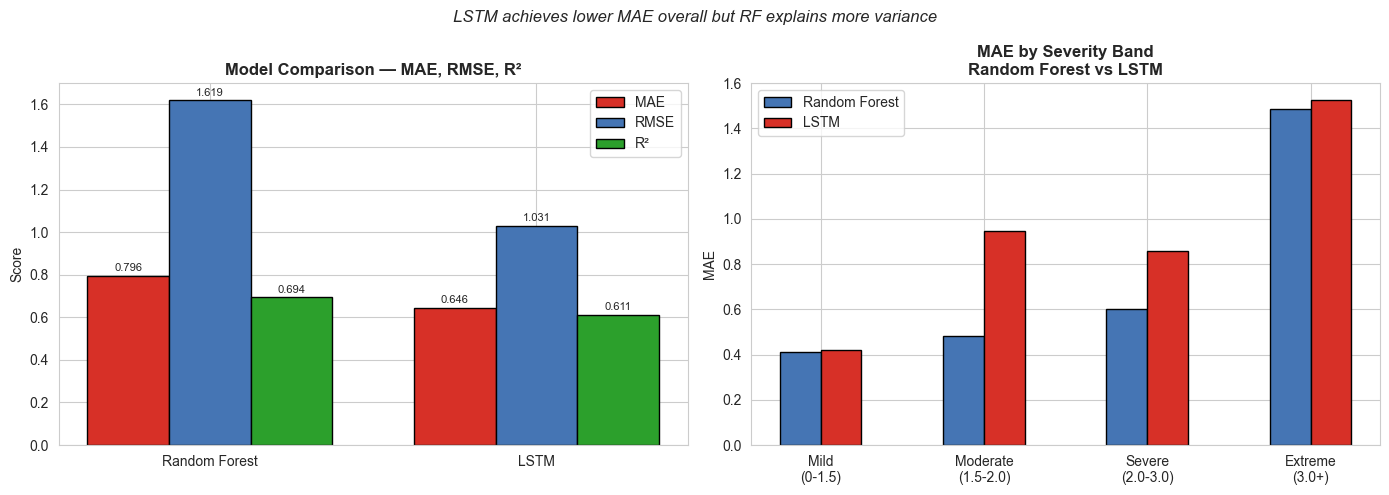

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models     = ['Random Forest', 'LSTM']
mae_vals   = [0.7962, mae]
rmse_vals  = [1.6194, rmse]
r2_vals    = [0.6937, r2]

x     = np.arange(len(models))
width = 0.25

axes[0].bar(x - width, mae_vals,  width, label='MAE',  color='#d73027', edgecolor='black')
axes[0].bar(x,         rmse_vals, width, label='RMSE', color='#4575b4', edgecolor='black')
axes[0].bar(x + width, r2_vals,   width, label='R²',   color='#2ca02c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title('Model Comparison — MAE, RMSE, R²', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
for bars in axes[0].containers:
    axes[0].bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

bands      = ['Mild\n(0-1.5)', 'Moderate\n(1.5-2.0)', 'Severe\n(2.0-3.0)', 'Extreme\n(3.0+)']
lstm_mae   = band_summary['mae'].values
rf_mae     = [0.410, 0.482, 0.603, 1.484]

x2 = np.arange(len(bands))
axes[1].bar(x2 - width/2, rf_mae,   width, label='Random Forest',
            color='#4575b4', edgecolor='black')
axes[1].bar(x2 + width/2, lstm_mae, width, label='LSTM',
            color='#d73027', edgecolor='black')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(bands)
axes[1].set_title('MAE by Severity Band\nRandom Forest vs LSTM', fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('LSTM achieves lower MAE overall but RF explains more variance',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

---
## Section 5: Summary

### What the LSTM adds over Random Forest

The Random Forest in Stage 2 used only job-level metadata available before
a job runs — CPU request, instance count, task count, and derived features.
It achieved R² = 0.694 on under-provisioned jobs.

The LSTM uses the actual sequence of CPU readings across instances, ordered
by sequence number. This gives it access to real observed behaviour — how
CPU usage evolves across the job's instances — rather than structural metadata.

### Results

| Metric | Random Forest | LSTM |
|--------|--------------|------|
| MAE    | 0.796        | 0.646 |
| RMSE   | 1.619        | 1.031 |
| R²     | 0.694        | 0.611 |

### Interpretation

- LSTM achieves 18.8% lower MAE and 36.4% lower RMSE than Random Forest
- Random Forest achieves higher R² — it explains more of the overall variance
- Both models struggle with extreme cases (util_ratio_peak > 3.0)
- LSTM is nearly unbiased overall (mean residual 0.006)

### Why LSTM has lower R² but better MAE/RMSE

R² penalises large errors heavily. The LSTM clips the target at the 95th
percentile during training, which limits its ability to predict extreme
values — this reduces R² but improves average-case accuracy (MAE/RMSE).
The Random Forest was trained without clipping, giving it an advantage on
the full variance range.

### Conclusion

The LSTM demonstrates that sequence-level CPU usage patterns contain
meaningful predictive signal beyond job metadata alone. For operational
deployment, a combined approach — using RF for flagging and LSTM for
severity estimation — would leverage the strengths of both models.